# EDA: Gene-Promoter Matrix
Exploratory analysis of the dataset before GMMVAE clustering.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', font_scale=1.1)
DATA_PATH = 'gene_promoter_matrix.txt'

## 1. Load Data

In [3]:
df_raw = pd.read_csv('gene_promoter_matrix.txt', sep='\t', index_col=0)
print(f'Shape (gene x sample): {df_raw.shape}')
df_raw.iloc[:5, :5]

Shape (gene x sample): (16938, 2801)


,SAMPLE 1,SAMPLE 2,SAMPLE 3,SAMPLE 4,SAMPLE 5
Gene,,,,,
C1orf114,0.032082,0.021114,0.016254,0.018251,0.025455
AK3L1,0.154140,0.055471,0.035271,0.048914,0.026775
PRPF38B,0.031538,0.030717,0.020517,0.037771,0.028425
C1orf74,0.032751,0.042916,0.020938,0.030671,0.029395
GLT25D2,0.000316,0.000292,0.000410,0.000320,0.000435


In [4]:
# Transpose to sample x gene (standard ML convention)
X = df_raw.T  # samples as rows
print(f'Shape (sample x gene): {X.shape}')
mat = X.values.astype(np.float32)
print(f'Value range: [{mat.min():.4f}, {mat.max():.4f}]')
print(f'Global mean: {mat.mean():.4f},  std: {mat.std():.4f}')
print(f'NaN count: {np.isnan(mat).sum()}')

Shape (sample x gene): (2801, 16938)
Value range: [0.0000, 0.9986]
Global mean: 0.2463,  std: 0.2847
NaN count: 0


## 2. Global Value Distribution

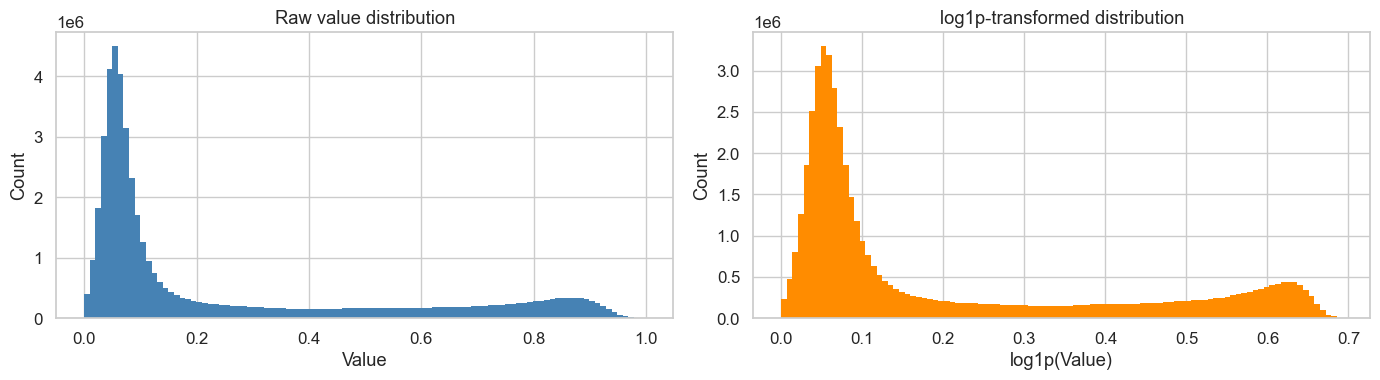

In [5]:
flat = mat.ravel()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(flat, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Raw value distribution')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')

log_flat = np.log1p(flat)
axes[1].hist(log_flat, bins=100, color='darkorange', edgecolor='none')
axes[1].set_title('log1p-transformed distribution')
axes[1].set_xlabel('log1p(Value)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('dist_global.png', dpi=150)
plt.show()

## 3. Per-Sample Statistics

In [6]:
sample_sum  = mat.sum(axis=1)
sample_mean = mat.mean(axis=1)
sample_std  = mat.std(axis=1)
sample_zeros = (mat == 0).sum(axis=1)
zero_pct = sample_zeros / mat.shape[1] * 100

stats_df = pd.DataFrame({
    'sum': sample_sum,
    'mean': sample_mean,
    'std': sample_std,
    'zero_pct': zero_pct
}, index=X.index)

print(stats_df.describe().round(4))

             sum       mean        std  zero_pct
count  2801.0000  2801.0000  2801.0000    2801.0
mean   4172.0757     0.2463     0.2828       0.0
std     410.2832     0.0242     0.0212       0.0
min    2530.3381     0.1494     0.1795       0.0
25%    3939.2576     0.2326     0.2702       0.0
50%    4139.8540     0.2444     0.2841       0.0
75%    4366.5171     0.2578     0.2949       0.0
max    6194.5781     0.3657     0.3452       0.0


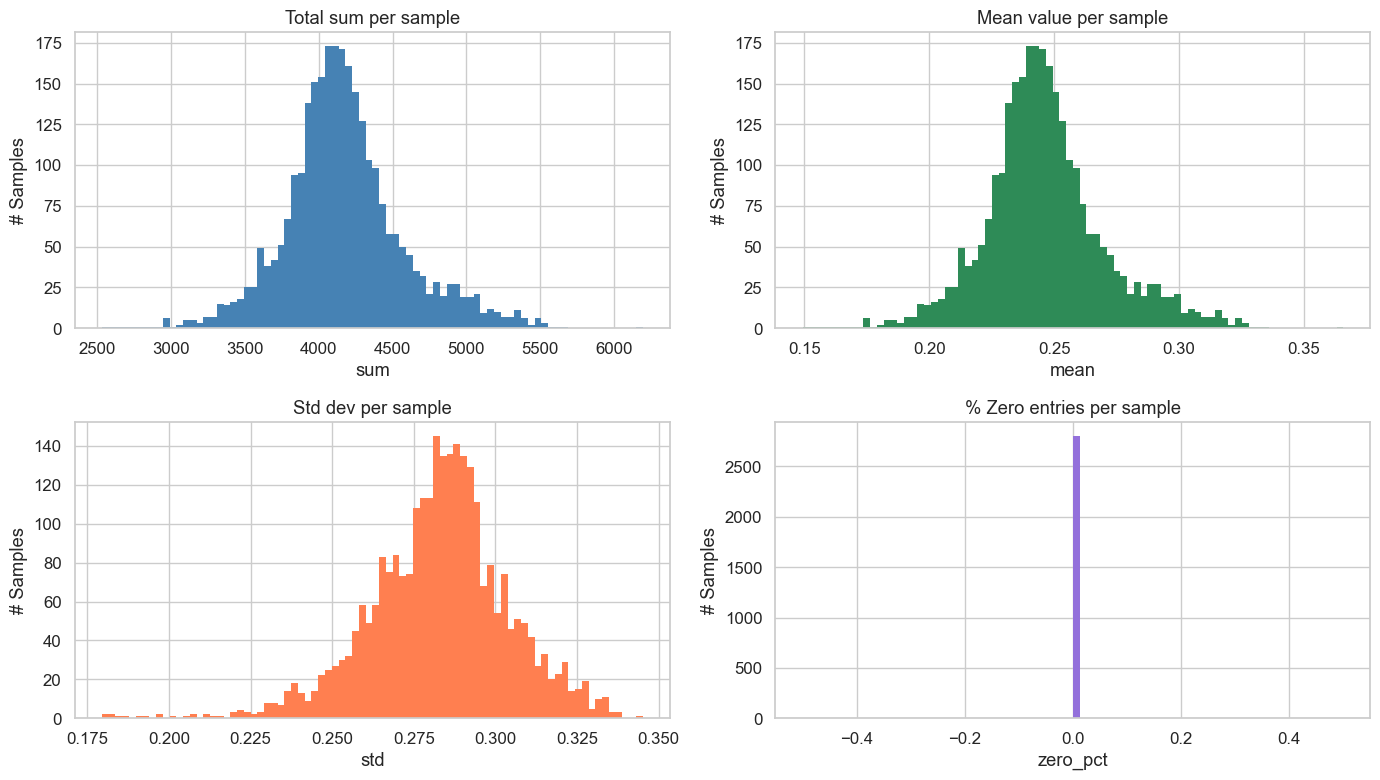

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col, color, title in zip(
    axes.ravel(),
    ['sum', 'mean', 'std', 'zero_pct'],
    ['steelblue', 'seagreen', 'coral', 'mediumpurple'],
    ['Total sum per sample', 'Mean value per sample',
     'Std dev per sample', '% Zero entries per sample']
):
    ax.hist(stats_df[col], bins=80, color=color, edgecolor='none')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('# Samples')

plt.tight_layout()
plt.savefig('dist_per_sample.png', dpi=150)
plt.show()

## 4. Per-Gene Statistics

In [8]:
gene_mean = mat.mean(axis=0)
gene_var  = mat.var(axis=0)
gene_zeros = (mat == 0).sum(axis=0)
gene_zero_pct = gene_zeros / mat.shape[0] * 100

gene_df = pd.DataFrame({
    'mean': gene_mean,
    'variance': gene_var,
    'zero_pct': gene_zero_pct
}, index=X.columns)

print(gene_df.describe().round(4))

             mean    variance  zero_pct
count  16938.0000  16938.0000   16938.0
mean       0.2463      0.0103       0.0
std        0.2660      0.0152       0.0
min        0.0045      0.0000       0.0
25%        0.0591      0.0003       0.0
50%        0.0951      0.0021       0.0
75%        0.4106      0.0155       0.0
max        0.9743      0.1089       0.0


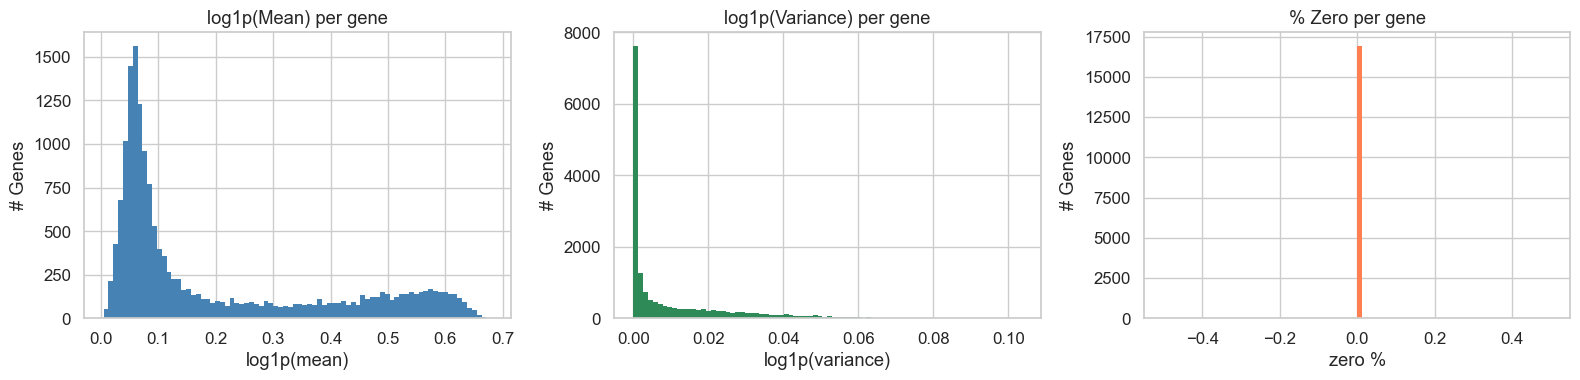

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(np.log1p(gene_df['mean']), bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('log1p(Mean) per gene')
axes[0].set_xlabel('log1p(mean)')
axes[0].set_ylabel('# Genes')

axes[1].hist(np.log1p(gene_df['variance']), bins=80, color='seagreen', edgecolor='none')
axes[1].set_title('log1p(Variance) per gene')
axes[1].set_xlabel('log1p(variance)')
axes[1].set_ylabel('# Genes')

axes[2].hist(gene_df['zero_pct'], bins=80, color='coral', edgecolor='none')
axes[2].set_title('% Zero per gene')
axes[2].set_xlabel('zero %')
axes[2].set_ylabel('# Genes')

plt.tight_layout()
plt.savefig('dist_per_gene.png', dpi=150)
plt.show()

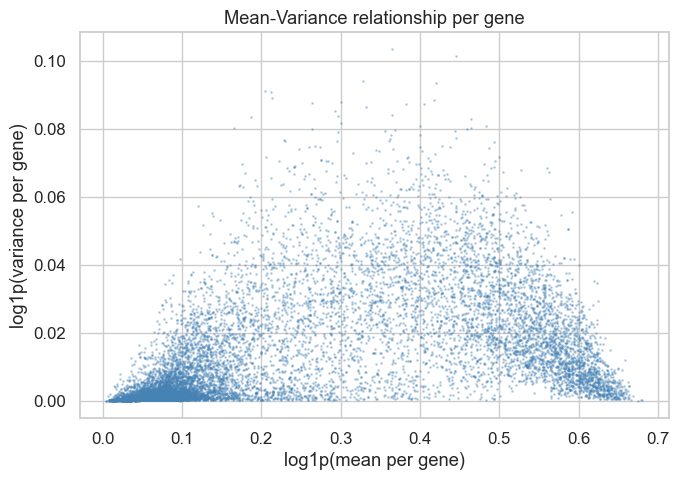

In [10]:
# Mean-Variance relationship (log scale)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(np.log1p(gene_df['mean']), np.log1p(gene_df['variance']),
           s=1, alpha=0.3, color='steelblue')
ax.set_xlabel('log1p(mean per gene)')
ax.set_ylabel('log1p(variance per gene)')
ax.set_title('Mean-Variance relationship per gene')
plt.tight_layout()
plt.savefig('mean_var_gene.png', dpi=150)
plt.show()

## 5. Low-Variance Gene Filtering Impact
Check how many genes survive at different variance thresholds.

 min_gene_var  genes_kept  pct_kept
     0.000000       16938     100.0
     0.000001       16938     100.0
     0.000010       16938     100.0
     0.000100       16629      98.2
     0.001000        9771      57.7
     0.005000        6863      40.5
     0.010000        5381      31.8
     0.050000         512       3.0
     0.100000           2       0.0


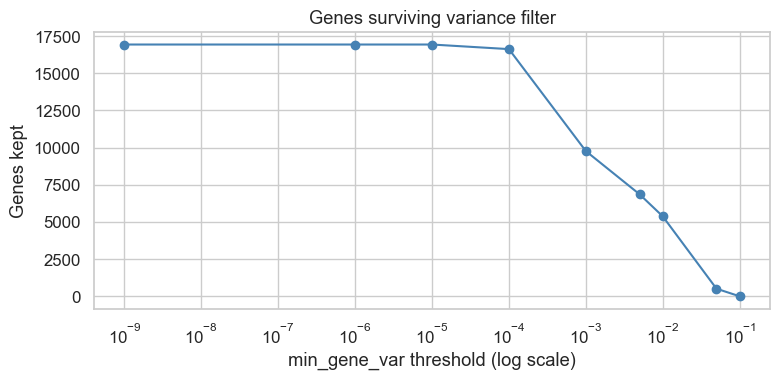

In [11]:
thresholds = [0, 1e-6, 1e-5, 1e-4, 1e-3, 0.005, 0.01, 0.05, 0.1]
surviving = [int((gene_df['variance'] >= t).sum()) for t in thresholds]

filt_df = pd.DataFrame({'min_gene_var': thresholds, 'genes_kept': surviving})
filt_df['pct_kept'] = (filt_df['genes_kept'] / len(gene_df) * 100).round(1)
print(filt_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx([max(t, 1e-9) for t in thresholds], surviving, 'o-', color='steelblue')
ax.set_xlabel('min_gene_var threshold (log scale)')
ax.set_ylabel('Genes kept')
ax.set_title('Genes surviving variance filter')
plt.tight_layout()
plt.savefig('gene_var_filter.png', dpi=150)
plt.show()

## 6. Inter-Sample Correlation
Sample a subset to check if samples are highly correlated (potential collapse cause).

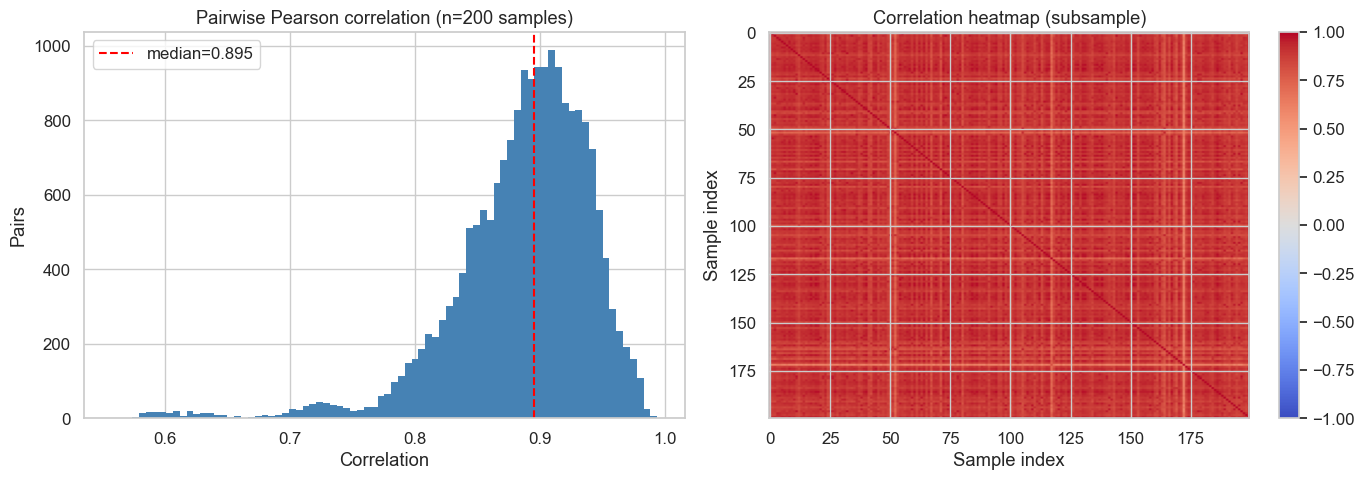

Correlation stats — mean: 0.8860, median: 0.8948, min: 0.5570, max: 0.9938


In [12]:
rng = np.random.default_rng(42)
n_subsample = min(200, mat.shape[0])
idx = rng.choice(mat.shape[0], n_subsample, replace=False)
sub = mat[idx]

corr = np.corrcoef(sub)  # n_subsample x n_subsample
upper = corr[np.triu_indices_from(corr, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(upper, bins=80, color='steelblue', edgecolor='none')
axes[0].set_title(f'Pairwise Pearson correlation (n={n_subsample} samples)')
axes[0].set_xlabel('Correlation')
axes[0].set_ylabel('Pairs')
axes[0].axvline(np.median(upper), color='red', linestyle='--', label=f'median={np.median(upper):.3f}')
axes[0].legend()

im = axes[1].imshow(corr, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title('Correlation heatmap (subsample)')
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('Sample index')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig('sample_correlation.png', dpi=150)
plt.show()

print(f'Correlation stats — mean: {upper.mean():.4f}, median: {np.median(upper):.4f}, '
      f'min: {upper.min():.4f}, max: {upper.max():.4f}')

## 7. PCA Overview
Check explained variance and whether any obvious structure exists.

/Users/kelaichen/.local/share/mamba/envs/gmvae/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/kelaichen/.local/share/mamba/envs/gmvae/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/kelaichen/.local/share/mamba/envs/gmvae/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/kelaichen/.local/share/mamba/envs/gmvae/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/kelaichen/.local/share/mamba/envs/gmvae/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/kelaichen/.local/share/mamba/envs/gmvae/lib/python3.10/site-packages/skl

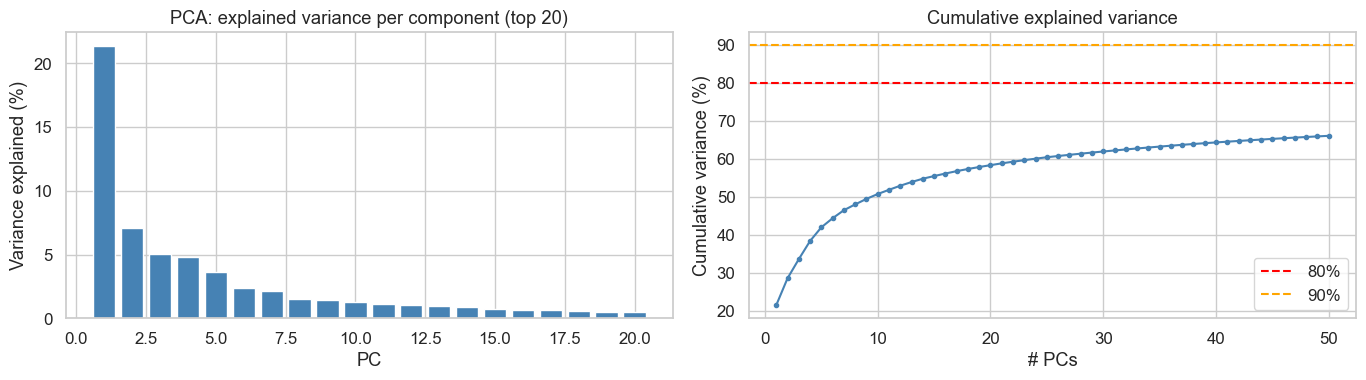

PCs needed for 80% variance: 51
PCs needed for 90% variance: 51


In [13]:
mat_log = np.log1p(mat)
scaler = StandardScaler()
mat_scaled = scaler.fit_transform(mat_log)

pca = PCA(n_components=50, random_state=42)
pca.fit(mat_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(1, 21), pca.explained_variance_ratio_[:20] * 100, color='steelblue')
axes[0].set_title('PCA: explained variance per component (top 20)')
axes[0].set_xlabel('PC')
axes[0].set_ylabel('Variance explained (%)')

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(range(1, 51), cumvar, 'o-', markersize=3, color='steelblue')
axes[1].axhline(80, color='red', linestyle='--', label='80%')
axes[1].axhline(90, color='orange', linestyle='--', label='90%')
axes[1].set_title('Cumulative explained variance')
axes[1].set_xlabel('# PCs')
axes[1].set_ylabel('Cumulative variance (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150)
plt.show()

n80 = int(np.searchsorted(cumvar, 80)) + 1
n90 = int(np.searchsorted(cumvar, 90)) + 1
print(f'PCs needed for 80% variance: {n80}')
print(f'PCs needed for 90% variance: {n90}')

/Users/kelaichen/.local/share/mamba/envs/gmvae/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kelaichen/.local/share/mamba/envs/gmvae/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kelaichen/.local/share/mamba/envs/gmvae/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/kelaichen/.local/share/mamba/envs/gmvae/lib/python3.10/site-packages/sklearn/decomposition/_base.py:155: RuntimeWarning: divide by zero encountered in matmul
  X_transformed -= xp.reshape(self.mean_, (1, -1)) @ self.components_.T
/Users/kelaichen/.local/share/mamba/envs/gmvae/lib/python3.10/site-packages/sklearn/decomposition/_base.py:155: RuntimeWarning: overflow encountered in 

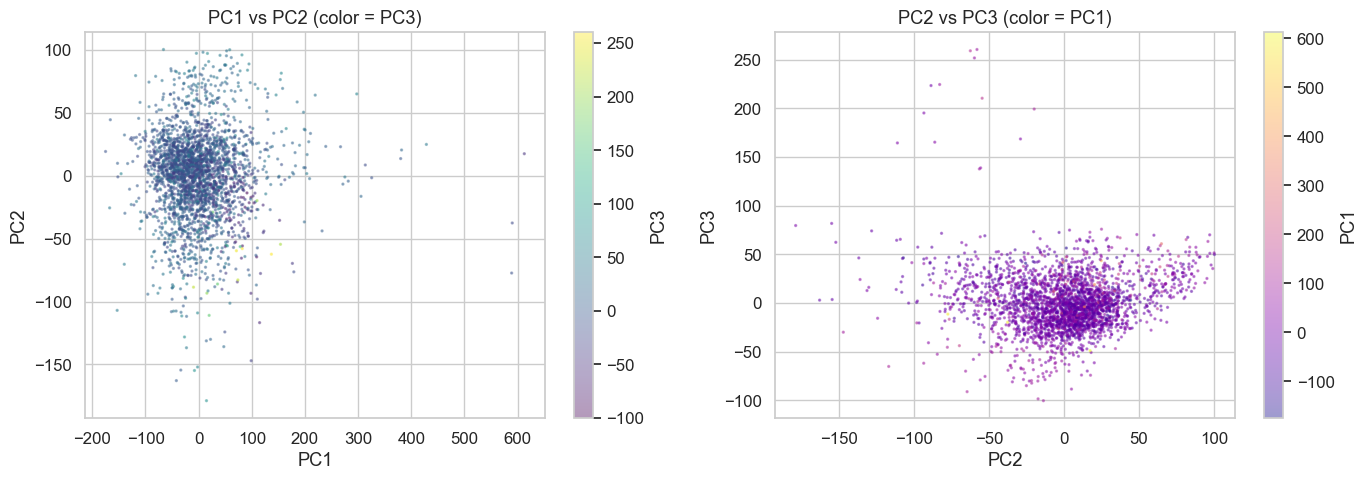

In [14]:
# Scatter on PC1 vs PC2, colored by PC3 value
coords = pca.transform(mat_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(coords[:, 0], coords[:, 1], s=2, alpha=0.4,
                     c=coords[:, 2], cmap='viridis')
axes[0].set_title('PC1 vs PC2 (color = PC3)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(sc, ax=axes[0], label='PC3')

sc2 = axes[1].scatter(coords[:, 1], coords[:, 2], s=2, alpha=0.4,
                      c=coords[:, 0], cmap='plasma')
axes[1].set_title('PC2 vs PC3 (color = PC1)')
axes[1].set_xlabel('PC2')
axes[1].set_ylabel('PC3')
plt.colorbar(sc2, ax=axes[1], label='PC1')

plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150)
plt.show()

## 8. Sparsity Summary

In [15]:
total_entries = mat.size
n_zeros = (mat == 0).sum()
near_zero = (mat < 1e-6).sum()

print(f'Total entries       : {total_entries:,}')
print(f'Exact zeros         : {n_zeros:,}  ({n_zeros/total_entries*100:.1f}%)')
print(f'Near-zero (<1e-6)   : {near_zero:,}  ({near_zero/total_entries*100:.1f}%)')
print(f'Samples             : {mat.shape[0]}')
print(f'Genes               : {mat.shape[1]}')

Total entries       : 47,443,338
Exact zeros         : 0  (0.0%)
Near-zero (<1e-6)   : 0  (0.0%)
Samples             : 2801
Genes               : 16938


## 9. Top Highly Variable Genes
These are the most informative genes for clustering.

In [16]:
top_n = 20
top_var_genes = gene_df.nlargest(top_n, 'variance')
print('Top 20 highest-variance genes:')
print(top_var_genes[['mean', 'variance', 'zero_pct']].round(5).to_string())

Top 20 highest-variance genes:
              mean  variance  zero_pct
Gene                                  
SCT        0.44035   0.10893       0.0
TSTD1      0.56067   0.10676       0.0
CCDC8      0.38809   0.09870       0.0
GABRA6     0.52202   0.09804       0.0
WNK2       0.22717   0.09536       0.0
KCNB1      0.23598   0.09529       0.0
TMEM106A   0.23862   0.09325       0.0
DDX56      0.51798   0.09259       0.0
HIST1H4F   0.35050   0.09207       0.0
VRK2       0.30159   0.09144       0.0
KRTAP10-6  0.50000   0.09135       0.0
MIR193A    0.46593   0.09116       0.0
MCHR2      0.39341   0.09047       0.0
SERPINB1   0.34102   0.08899       0.0
SDPR       0.44080   0.08770       0.0
MARVELD2   0.34575   0.08749       0.0
PION       0.20605   0.08702       0.0
TNFAIP6    0.59190   0.08644       0.0
MGP        0.34998   0.08522       0.0
C17orf107  0.49228   0.08430       0.0


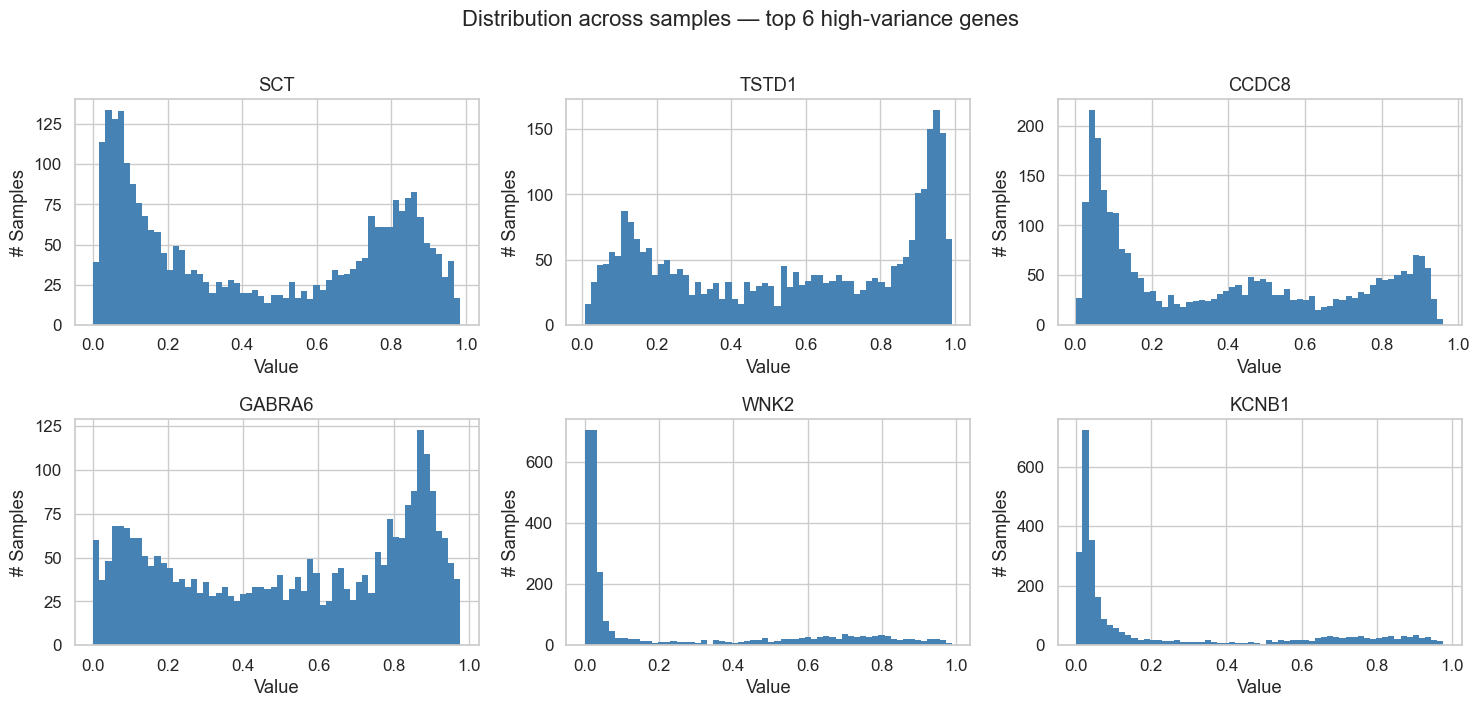

In [17]:
# Distribution of top 6 high-variance genes across samples
top6 = top_var_genes.index[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, gene in zip(axes.ravel(), top6):
    vals = X[gene].values
    ax.hist(vals, bins=60, color='steelblue', edgecolor='none')
    ax.set_title(gene)
    ax.set_xlabel('Value')
    ax.set_ylabel('# Samples')
plt.suptitle('Distribution across samples — top 6 high-variance genes', y=1.01)
plt.tight_layout()
plt.savefig('top_var_genes.png', dpi=150, bbox_inches='tight')
plt.show()